# Hennepin County: Mortgage Lending Bias Analysis
### Jay Beladiya



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Hennepin County's Minnesota county code is 053, so the full FIPS code is 27053
COUNTY_FIPS = "27053"

df = pd.read_csv("../../Data/mortgage_covenant_data.csv")

# census_tract starts with the county code, so we use the first 5 digits to filter counties
df["county_fips"] = df["census_tract"].dropna().astype("int64").astype(str).str[:5]
county = df[df["county_fips"] == COUNTY_FIPS].copy()

print(f"Rows for county {COUNTY_FIPS}: {len(county)}")
county.head()

Rows for county 27053: 22669


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density,county_fips
19,2023,2.705303e+10,Race Not Available,6,445000.0,455000.0,NaN,7.625,39.47,100.56,10,0.0,False,NaN,27053
36,2023,2.705301e+10,Race Not Available,6,265000.0,275000.0,NaN,3.250,29.71,98.77,10,68.0,False,Medium (51-100),27053
68,2023,2.705303e+10,White,1,315000.0,425000.0,NaN,8.250,12.84,159.62,10,2.0,True,Low (1-50),27053
69,2023,2.705303e+10,White,4,515000.0,NaN,210.0,NaN,11.59,113.96,10,76.0,False,Medium (51-100),27053
70,2023,2.705301e+10,White,1,665000.0,785000.0,182.0,8.625,41.44,15.77,10,0.0,True,NaN,27053


## Cleaning up the covenant density column

`covenant_density` is blank for any census tract that had zero historical covenants recorded, so I relabelled those rows as `"None"` and put all five categories in a logical low-to-high order for the charts.

In [3]:
county["covenant_density"] = county["covenant_density"].fillna("None")

density_order = ["None", "Low (1-50)", "Medium (51-100)", "High (101-200)", "Very High (>200)"]
county["covenant_density"] = pd.Categorical(county["covenant_density"], categories=density_order, ordered=True)

county["covenant_density"].value_counts().sort_index()

covenant_density
None                11500
Low (1-50)           4537
Medium (51-100)      1772
High (101-200)       1720
Very High (>200)     3140
Name: count, dtype: int64

## Part 1: Data Bias

covenant_density
None                501293.300145
Low (1-50)          418831.701508
Medium (51-100)     567187.500000
High (101-200)      547739.916551
Very High (>200)    506902.255639
Name: property_value, dtype: float64


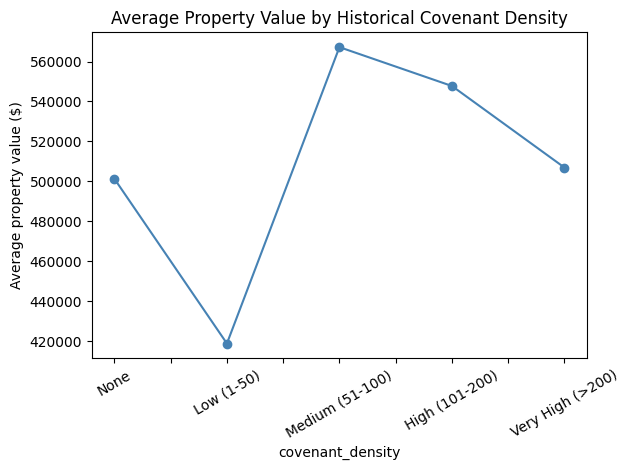

In [4]:
# Average property value by covenant density level
avg_value = county.groupby("covenant_density", observed=False)["property_value"].mean()
print(avg_value)

avg_value.plot(kind="line", marker="o", color="steelblue")
plt.ylabel("Average property value ($)")
plt.title("Average Property Value by Historical Covenant Density")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../../Analysis/property_value_by_covenant_density.png")
plt.show()

covenant_density
None                34.818958
Low (1-50)          37.501120
Medium (51-100)     26.929069
High (101-200)      24.150360
Very High (>200)    25.431010
Name: tract_minority_population_percent, dtype: float64


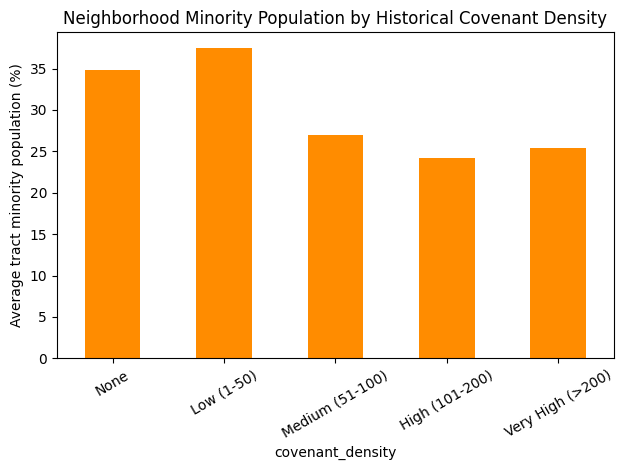

In [5]:
# Average neighborhood minority population percentage by covenant density level
avg_minority = county.groupby("covenant_density", observed=False)["tract_minority_population_percent"].mean()
print(avg_minority)

avg_minority.plot(kind="bar", color="darkorange")
plt.ylabel("Average tract minority population (%)")
plt.title("Neighborhood Minority Population by Historical Covenant Density")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../../Analysis/minority_percent_by_covenant_density.png")
plt.show()

covenant_density
None                110.348786
Low (1-50)           99.387064
Medium (51-100)     112.761580
High (101-200)      116.914163
Very High (>200)    123.291271
Name: tract_to_msa_income_percentage, dtype: float64


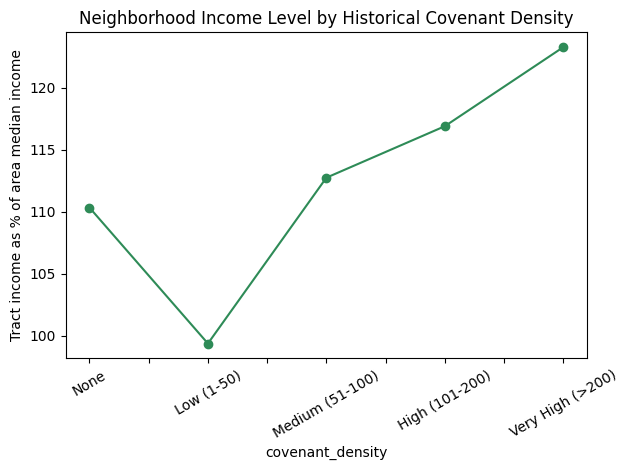

In [6]:
# Average neighborhood income, relative to the metro area's median income, by covenant density level
avg_income_ratio = county.groupby("covenant_density", observed=False)["tract_to_msa_income_percentage"].mean()
print(avg_income_ratio)

avg_income_ratio.plot(kind="line", marker="o", color="seagreen")
plt.ylabel("Tract income as % of area median income")
plt.title("Neighborhood Income Level by Historical Covenant Density")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../../Analysis/income_by_covenant_density.png")
plt.show()

*Interpretation:* The average value of properties is significantly higher in the Medium and High covenant-density tracts ($567K and $548K respectively) than in Low-density tracts ($419K); the None and Very High tracts fall somewhere between the former and latter (average values of $501K and $507K respectively). Thus, the effect of covenant density on property values is not linearly correlated, but generally positively correlated. The share of minority population follows the exact opposite pattern: it is highest in tracts with no covenants or Low density of covenants (35-38%), and significantly lower in Medium/High/Very High density tracts (24-27%). Neighborhood income, relative to the median income for the area, grows consistently with the increasing covenant density, starting from 99% in Low-density tracts and reaching 123% in Very High tracts. In total, this constitutes the **data bias** effect: the neighborhoods that had higher levels of historically active covenants in the past tend to be whiter, wealthier, and more expensive today than those neighborhoods that had no or few covenants — more than 70 years after covenants were outlawed.

## Part 2: Algorithmic Bias

derived_race
Race Not Available                           0.418895
American Indian or Alaska Native             0.578231
2 or more minority races                     0.595238
Black or African American                    0.599432
Native Hawaiian or Other Pacific Islander    0.666667
Asian                                        0.702801
White                                        0.764393
Joint                                        0.773060
Name: was_approved, dtype: float64


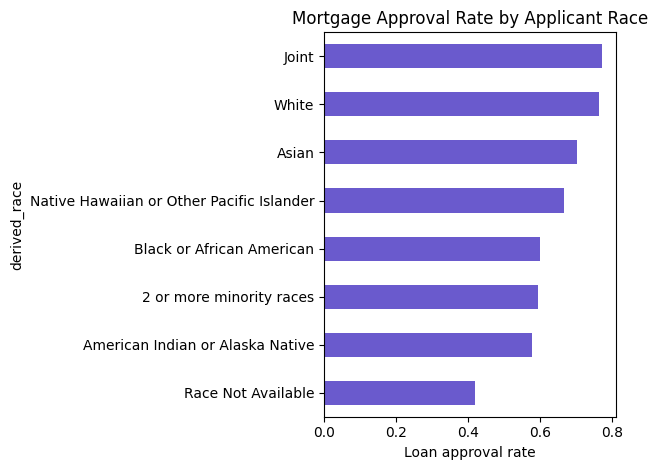

In [7]:
# Loan approval rate by applicant race
approval_by_race = county.groupby("derived_race")["was_approved"].mean().sort_values()
print(approval_by_race)

approval_by_race.plot(kind="barh", color="slateblue")
plt.xlabel("Loan approval rate")
plt.title("Mortgage Approval Rate by Applicant Race")
plt.tight_layout()
plt.savefig("../../Analysis/approval_rate_by_race.png")
plt.show()

covenant_density
None                0.649826
Low (1-50)          0.661230
Medium (51-100)     0.670429
High (101-200)      0.692442
Very High (>200)    0.673885
Name: was_approved, dtype: float64


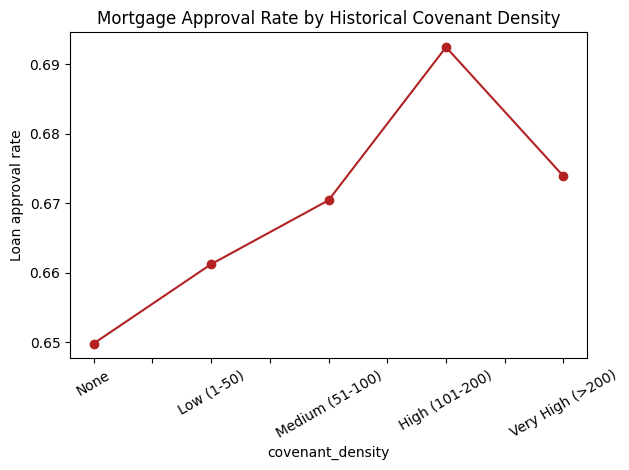

In [8]:
# Loan approval rate by covenant density level
approval_by_density = county.groupby("covenant_density", observed=False)["was_approved"].mean()
print(approval_by_density)

approval_by_density.plot(kind="line", marker="o", color="firebrick")
plt.ylabel("Loan approval rate")
plt.title("Mortgage Approval Rate by Historical Covenant Density")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../../Analysis/approval_rate_by_covenant_density.png")
plt.show()

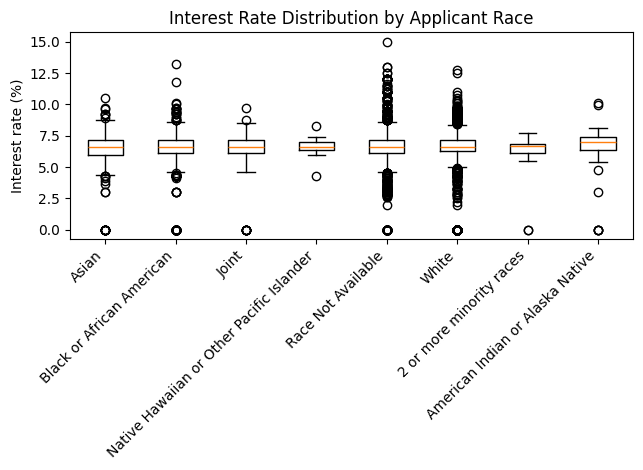

In [9]:
# Distribution of interest rates by applicant race (only set for loans that were actually originated)
race_order = county.groupby("derived_race")["interest_rate"].median().sort_values().index
rate_by_race = [county[county["derived_race"] == r]["interest_rate"].dropna() for r in race_order]

plt.boxplot(rate_by_race, tick_labels=race_order)
plt.ylabel("Interest rate (%)")
plt.title("Interest Rate Distribution by Applicant Race")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../../Analysis/interest_rate_by_race.png")
plt.show()

denial_reason
Debt-to-income ratio             366
Collateral                       191
Other                             94
Credit history                    88
Credit application incomplete     67
Unverifiable information          61
Insufficient cash                 48
Employment history                37
Name: count, dtype: int64


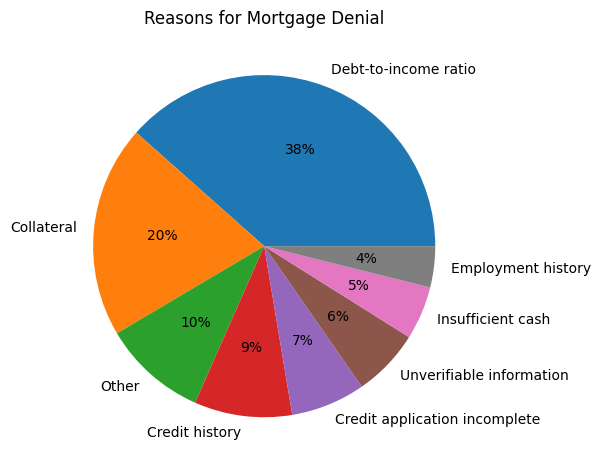

In [10]:
# Reasons given for mortgage denial
denial_reason_labels = {
    1: "Debt-to-income ratio",
    2: "Employment history",
    3: "Credit history",
    4: "Collateral",
    5: "Insufficient cash",
    6: "Unverifiable information",
    7: "Credit application incomplete",
    8: "Mortgage insurance denied",
    9: "Other",
}

denied = county[county["action_taken"] == 3].copy()
denied["denial_reason"] = denied["denial_reason-1"].map(denial_reason_labels)

reason_counts = denied["denial_reason"].value_counts()
print(reason_counts)

reason_counts.plot(kind="pie", autopct="%1.0f%%")
plt.ylabel("")
plt.title("Reasons for Mortgage Denial")
plt.tight_layout()
plt.savefig("../../Analysis/denial_reasons.png")
plt.show()

## Part 3: Proxy Variables

Race is not an input to the lending decision, but neighborhood variables shaped by historical discrimination (like minority population percentage or covenant density) could act as **proxies** for race. Here we check whether the race gap in approval rates still shows up once we hold the neighborhood's covenant density level fixed.

derived_race      Black or African American     White
covenant_density                                     
None                               0.610342  0.760984
Low (1-50)                         0.578454  0.753737
Medium (51-100)                    0.592233  0.778605
High (101-200)                     0.608696  0.773451
Very High (>200)                   0.574257  0.775687


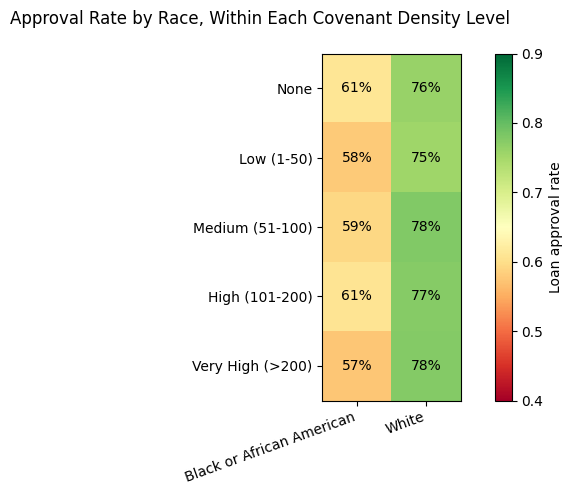

In [11]:
# Compare approval rates for the two largest racial groups, within each covenant density level
main_races = ["White", "Black or African American"]
subset = county[county["derived_race"].isin(main_races)]

approval_table = subset.groupby(["covenant_density", "derived_race"], observed=False)["was_approved"].mean().unstack()
print(approval_table)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(approval_table.values, cmap="RdYlGn", vmin=0.4, vmax=0.9)

ax.set_xticks(range(len(approval_table.columns)))
ax.set_xticklabels(approval_table.columns, rotation=20, ha="right")
ax.set_yticks(range(len(approval_table.index)))
ax.set_yticklabels(approval_table.index)

for i in range(len(approval_table.index)):
    for j in range(len(approval_table.columns)):
        ax.text(j, i, f"{approval_table.values[i, j]:.0%}", ha="center", va="center")

plt.colorbar(im, label="Loan approval rate")
fig.suptitle("Approval Rate by Race, Within Each Covenant Density Level")
plt.tight_layout()
plt.savefig("../../Analysis/approval_rate_by_race_and_density.png")
plt.show()

                                   tract_minority_population_percent  \
tract_minority_population_percent                           1.000000   
was_approved                                               -0.051283   

                                   was_approved  
tract_minority_population_percent     -0.051283  
was_approved                           1.000000  


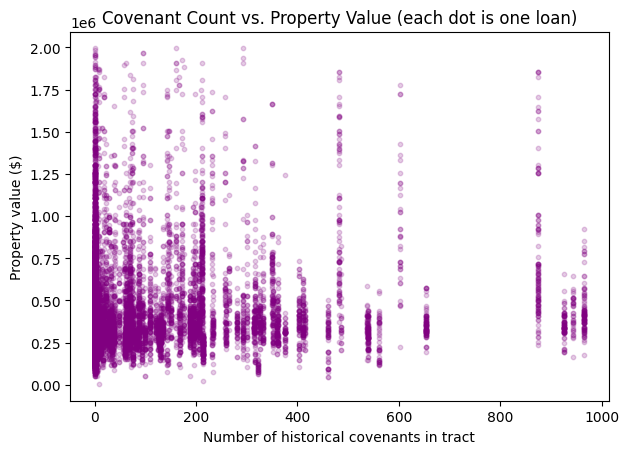

In [12]:
# does neighborhood minority percentage line up with loan approval,
# even though race itself is never an input to the lending decision?
correlation = county[["tract_minority_population_percent", "was_approved"]].corr()
print(correlation)

# Scatter plot of the raw, non-binned relationship between covenant count and property value
# (a handful of extreme outlier property values are excluded)
typical_homes = county[county["property_value"] <= 2_000_000]
plt.scatter(typical_homes["covenant_count"], typical_homes["property_value"], alpha=0.2, s=10, color="purple")
plt.xlabel("Number of historical covenants in tract")
plt.ylabel("Property value ($)")
plt.title("Covenant Count vs. Property Value (each dot is one loan)")
plt.tight_layout()
plt.savefig("../../Analysis/covenant_count_vs_property_value.png")
plt.show()

## Summary

- **Data bias findings:** Historically covenanted tracts in Hennepin County are whiter, higher-income, and higher-value today than tracts with little or no covenant history. The pattern isn't perfectly linear, but consistently, greater number of covenants is associated with smaller proportion of minority residents and greater proportion of relative income.
- **Algorithmic bias findings:** Approval rates vary widely between racial groups – 76.4% for White people against 59.9% for Black applicants (discrepancy of 16.5%). Approvals rates based on covenant density differ much less (approximately 65%-69% regardless of density level). Debt-to-income ratio is by far the most often listed reason for denial. Interest rate box plot demonstrates that simply comparing averages is meaningless because of large overlap between interquartile ranges in all racial groups (approximately 6.1%-7.4%).
- **Proxy variable findings:** Using the heat map, it is easy to note that the Black/White approval rate gap maintains itself consistently large (of about 15-20 percentage points) regardless of the level of covenant density for each density group, even in the group of tracts with no recorded covenants. As such, if covenant density was driving the racial gap, the gap would have been smaller in tracts with little or no covenant density, which is not the case – thus there must be another race-related characteristic outside the dataset (income, credit history, down payment) that plays a stronger role. It should also be noted that the scatterplot presents a crucial caveat to the part 1 result on bias in the data: at the loan-level, covenant density and property value do not exhibit significant correlation (r ≈ 0.01).

## Part 4: Hennepin vs. Ramsey County Comparison

In [13]:
counties = {"27053": "Hennepin", "27123": "Ramsey"}

both = df[df["county_fips"].isin(counties)].copy()
both["county_name"] = both["county_fips"].map(counties)

both["covenant_density"] = both["covenant_density"].fillna("None")
both["covenant_density"] = pd.Categorical(both["covenant_density"], categories=density_order, ordered=True)

both.groupby("county_name").size()

county_name
Hennepin    22669
Ramsey       8782
dtype: int64

### Data bias

county_name            Hennepin         Ramsey
covenant_density                              
None              501293.300145  367085.372485
Low (1-50)        418831.701508  388451.035782
Medium (51-100)   567187.500000  333084.033613
High (101-200)    547739.916551  408108.348135
Very High (>200)  506902.255639  348309.352518


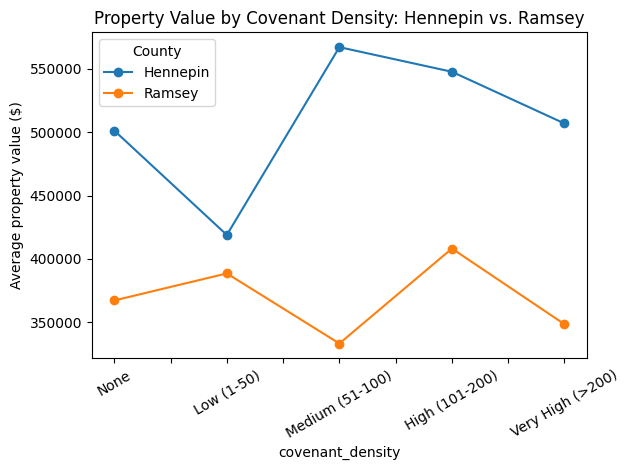

In [14]:
# Average property value by covenant density, side by side for each county
value_by_county = both.groupby(["covenant_density", "county_name"], observed=False)["property_value"].mean().unstack()
print(value_by_county)

value_by_county.plot(kind="line", marker="o")
plt.ylabel("Average property value ($)")
plt.title("Property Value by Covenant Density: Hennepin vs. Ramsey")
plt.xticks(rotation=30)
plt.legend(title="County")
plt.tight_layout()
plt.savefig("../../Analysis/compare_property_value_by_density.png")
plt.show()

county_name        Hennepin     Ramsey
covenant_density                      
None              34.818958  47.683301
Low (1-50)        37.501120  38.250346
Medium (51-100)   26.929069  33.876521
High (101-200)    24.150360  32.898328
Very High (>200)  25.431010  27.835214


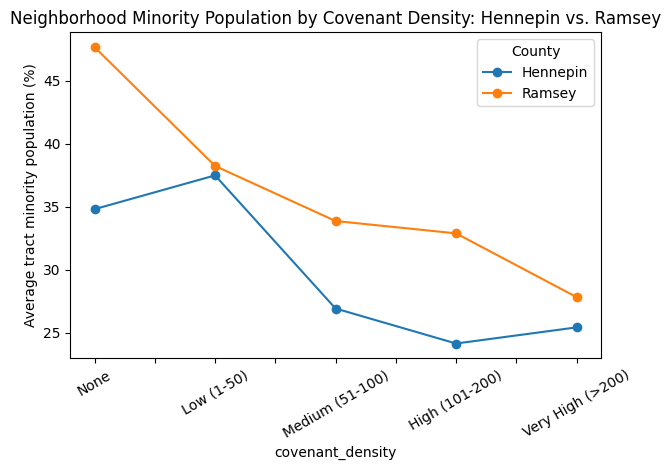

In [15]:
# Average neighborhood minority population percentage by covenant density, side by side
minority_by_county = both.groupby(["covenant_density", "county_name"], observed=False)["tract_minority_population_percent"].mean().unstack()
print(minority_by_county)

minority_by_county.plot(kind="line", marker="o")
plt.ylabel("Average tract minority population (%)")
plt.title("Neighborhood Minority Population by Covenant Density: Hennepin vs. Ramsey")
plt.xticks(rotation=30)
plt.legend(title="County")
plt.tight_layout()
plt.savefig("../../Analysis/compare_minority_percent_by_density.png")
plt.show()

county_name         Hennepin      Ramsey
covenant_density                        
None              110.348786   84.692129
Low (1-50)         99.387064   88.268710
Medium (51-100)   112.761580   97.234356
High (101-200)    116.914163   97.411405
Very High (>200)  123.291271  102.546151


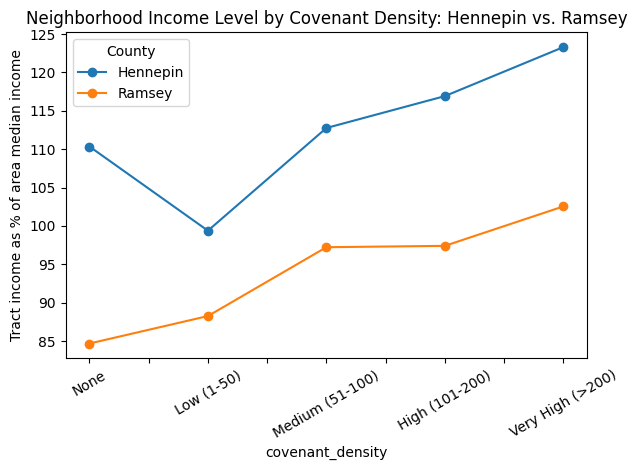

In [16]:
# Average neighborhood income (relative to area median income) by covenant density, side by side
income_by_county = both.groupby(["covenant_density", "county_name"], observed=False)["tract_to_msa_income_percentage"].mean().unstack()
print(income_by_county)

income_by_county.plot(kind="line", marker="o")
plt.ylabel("Tract income as % of area median income")
plt.title("Neighborhood Income Level by Covenant Density: Hennepin vs. Ramsey")
plt.xticks(rotation=30)
plt.legend(title="County")
plt.tight_layout()
plt.savefig("../../Analysis/compare_income_by_density.png")
plt.show()

### Algorithmic bias

county_name       Hennepin    Ramsey
covenant_density                    
None              0.649826  0.635294
Low (1-50)        0.661230  0.659164
Medium (51-100)   0.670429  0.664781
High (101-200)    0.692442  0.674556
Very High (>200)  0.673885  0.680244


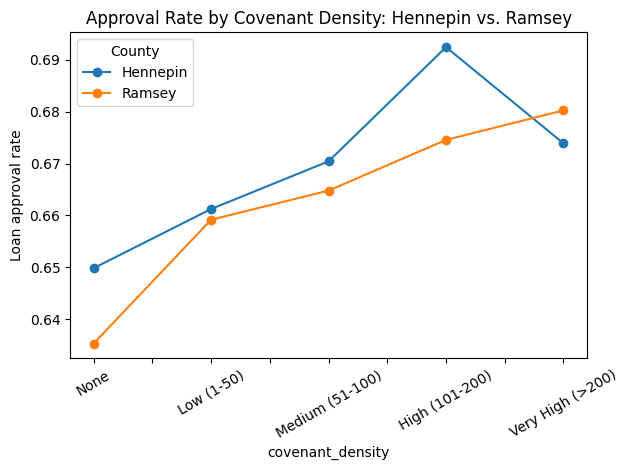

In [17]:
# Loan approval rate by covenant density, side by side
approval_by_county = both.groupby(["covenant_density", "county_name"], observed=False)["was_approved"].mean().unstack()
print(approval_by_county)

approval_by_county.plot(kind="line", marker="o")
plt.ylabel("Loan approval rate")
plt.title("Approval Rate by Covenant Density: Hennepin vs. Ramsey")
plt.xticks(rotation=30)
plt.legend(title="County")
plt.tight_layout()
plt.savefig("../../Analysis/compare_approval_rate_by_density.png")
plt.show()

county_name                                Hennepin    Ramsey
derived_race                                                 
2 or more minority races                   0.595238  0.642857
American Indian or Alaska Native           0.578231  0.690141
Asian                                      0.702801  0.687558
Black or African American                  0.599432  0.569536
Joint                                      0.773060  0.768293
Native Hawaiian or Other Pacific Islander  0.666667  0.714286
Race Not Available                         0.418895  0.432900
White                                      0.764393  0.741232


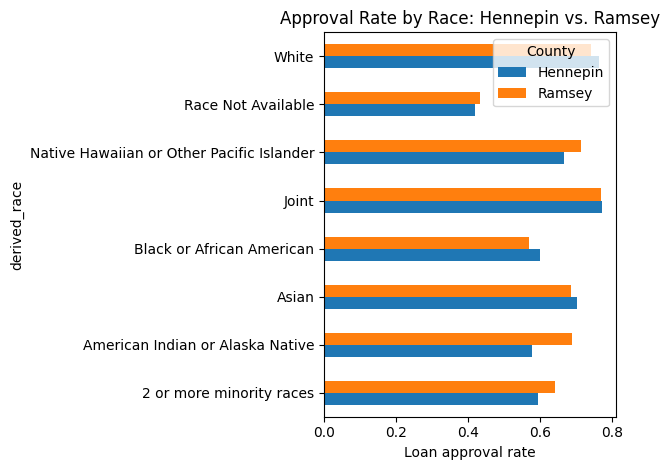

In [18]:
# Loan approval rate by race, side by side for each county
approval_by_race_county = both.groupby(["derived_race", "county_name"])["was_approved"].mean().unstack()
print(approval_by_race_county)

approval_by_race_county.plot(kind="barh")
plt.xlabel("Loan approval rate")
plt.title("Approval Rate by Race: Hennepin vs. Ramsey")
plt.legend(title="County")
plt.tight_layout()
plt.savefig("../../Analysis/compare_approval_rate_by_race.png")
plt.show()

### Overall summary table

In [19]:
summary = both.groupby("county_name").agg(
    num_loans=("was_approved", "size"),
    overall_approval_rate=("was_approved", "mean"),
    avg_property_value=("property_value", "mean"),
    avg_minority_percent=("tract_minority_population_percent", "mean"),
    avg_income_ratio=("tract_to_msa_income_percentage", "mean"),
)
summary

,num_loans,overall_approval_rate,avg_property_value,avg_minority_percent,avg_income_ratio
county_name,,,,,
Hennepin,22669,0.660285,494417.021500,32.629181,110.634374
Ramsey,8782,0.649966,372564.050427,41.651573,88.692407


## County Comparison Summary

- **Similarities:** Both counties show the same underlying patterns. Historically covenanted tracts are whiter and higher-income today than tracts without covenant history (cleaner and more monotonic in Ramsey than in Hennepin). Both counties show a large, consistent racial gap in approval rates (Hennepin: White 76.4% vs. Black 59.9%, a 16.5-point gap; Ramsey: White 74.1% vs. Black 57.0%, a 17.1-point gap) that is far bigger than the gap explained by covenant density alone (a 3-4 point spread in both counties). Debt-to-income ratio is the leading denial reason in both counties.
- **Differences:** Ramsey County is more racially diverse (41.7% avg. tract minority population vs. 32.6% in Hennepin) and lower-income (88.7% vs. 110.6% avg. income ratio) and has far fewer recorded covenants than Hennepin (5,528 vs. ~30,000), which may itself be a limitation rather than a true historical difference. Despite these underlying differences, overall approval rates are nearly identical (66.0% Hennepin vs. 65.0% Ramsey) — suggesting the racial disparity in lending outcomes isn't specific to one county's circumstances.